In [3]:
import os
import numpy as np
from tqdm import tqdm
import pandas as pd
import random
import sys

import matplotlib.pyplot as plt
# pytorch
import torch
from torch.utils.data import Dataset, Sampler
sys.path.append('/home/agustin/phd/synthesis')


import utils.nifti_functions as nfc
import utils.util as util
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs
import utils.gpu_selector as gpu_selector
import data_loaders.load_dataset as load_dataset
import utils.data_normalization as data_normalization

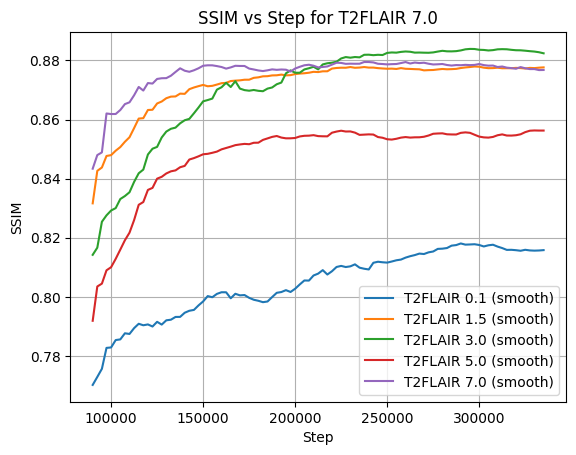

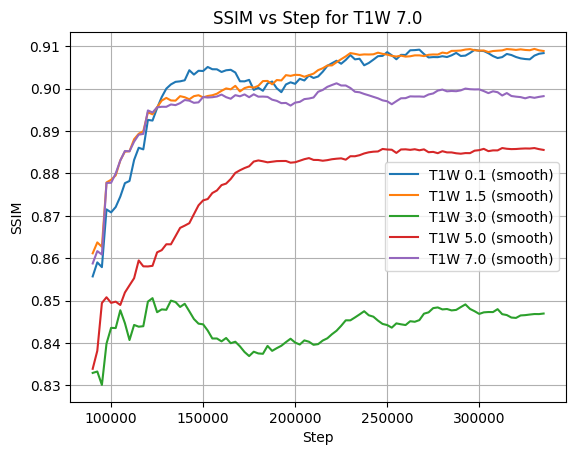

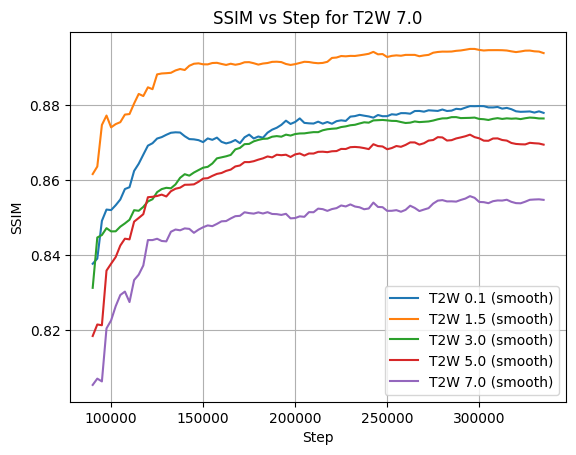

In [5]:
models_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/test5_segmentation_prior/training/models/all_357t/segconcatenated_synthsr"
model_name = "test2_merged3_4res_probseg_nofgr_combined_data"
# model_name = "test2_merged3_4res_probseg_nofgr_combined_data_refined"


csv_files = []
for root, dirs, files in os.walk(os.path.join(models_path, model_name)):
    for file in files:
        if file.startswith("metrics") and file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))
    
complete_csv = []
for file in csv_files:
    # print(f"Reading file {os.path.basename(file).split('step_')[1].split('_metrics.csv')[0]}")
    df = pd.read_csv(file)
    step = int(os.path.basename(file).split("_")[-1].split(".")[0])
    df["step"] = step
    complete_csv.append(df)

complete_csv = pd.concat(complete_csv, ignore_index=True)
# sort complete_csv by step number
complete_csv = complete_csv.sort_values(by="step")
# remove step 1 from complete_csv
complete_csv = complete_csv[complete_csv["step"] != 1]


unique_ids = complete_csv["sid"].unique()
unique_modalitites = complete_csv["modality"].unique()
unique_resolutions = complete_csv["resolution"].unique()

# sor resolution in ascending order it is  float, so we can sort it as float
unique_resolutions = sorted(unique_resolutions, key=lambda x: float(x))

# sort unique resolution in ascending order
# seed,sid,modality,resolution,modality_idx,resolution_idx,use_synthsr,ssim,rmse

complete_csv = complete_csv.sort_values(by=["modality", "resolution", "step"])
metric = "ssim"
for modality in unique_modalitites:
    for resolution in unique_resolutions:
        df = complete_csv[(complete_csv["modality"] == modality) & (complete_csv["resolution"] == resolution)].copy()
        # plt.plot(df["step"], df[metric], label=f"{modality} {resolution}")
        
                # # make smooth the curve with a rolling mean of window size 3
        df[metric + "_smooth"] = df[metric].rolling(window=10).mean()
        plt.plot(df["step"], df[metric + "_smooth"], label=f"{modality} {resolution} (smooth)")

    plt.xlabel("Step")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs Step for {modality} {resolution}")
    plt.legend()
    plt.grid()
    plt.show()



In [29]:
models_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/test5_segmentation_prior/training/models/all_357t/segconcatenated_synthsr"
# model_name = "test1_T1W_5T_7T"
# model_name = "test1_other_loses"
# model_name = "test1_T1W_0.1T_7T"
model_name = "test2_merged3_4res_probseg_nofgr_combined_data"

# "summary_volumes_diff_percent_step_100.csv"

# read all the files containing "summary_volumes_diff_percent_step_***.csv" in the name in any of the subfolders of models_path, sort them by the number after "summary_volumes_diff_percent_step_" and print the sorted list of files
csv_files = []
for root, dirs, files in os.walk(os.path.join(models_path, model_name)):
    for file in files:
        if file.startswith("step_") and file.endswith("_metrics.csv"):
            csv_files.append(os.path.join(root, file))
# csv_files = sorted(csv_files, key=lambda x: int(x.split("step_")[1].split("_metrics.csv")[0]))

# read csvs
complete_csv = []
for file in csv_files:
    # print(f"Reading file {os.path.basename(file).split('step_')[1].split('_metrics.csv')[0]}")
    df = pd.read_csv(file)
    step = int(os.path.basename(file).split("step_")[1].split("_metrics.csv")[0])
    df["step"] = step
    complete_csv.append(df)

complete_csv = pd.concat(complete_csv, ignore_index=True)
# sort complete_csv by step number
complete_csv = complete_csv.sort_values(by="step")
# remove step 1 from complete_csv
complete_csv = complete_csv[complete_csv["step"] != 1]

unique_ids = complete_csv["subject_id"].unique()
unique_modalitites = complete_csv["modality"].unique()
unique_resolutions = complete_csv["resolution"].unique()

# sort unique resolution in ascending order
unique_resolutions = sorted(unique_resolutions, key=lambda x: int(x))

metric_to_plot = "ssim" #mse,mae,ssim
for modality in unique_modalitites:
    for resolution in unique_resolutions:
        # plot the evolution of the columns ssim with respect to the step number for the rows with modality and resolution
        results_df = complete_csv[(complete_csv["modality"] == modality) & (complete_csv["resolution"] == resolution)]
        plt.plot(results_df["step"], results_df[metric_to_plot], label=f"{modality} {resolution}")

        # # make smooth the curve with a rolling mean of window size 3
        # results_df[metric_to_plot + "_smooth"] = results_df[metric_to_plot].rolling(window=3).mean()
        # plt.plot(results_df["step"], results_df[metric_to_plot + "_smooth"], label=f"{modality} {resolution} (smooth)")

    plt.xlabel("Step number")
    plt.ylabel("Value")
    plt.title(f"Evolution of values with respect to step number for modality {modality} and resolution {resolution}")
    plt.legend()
    plt.show()






ValueError: No objects to concatenate

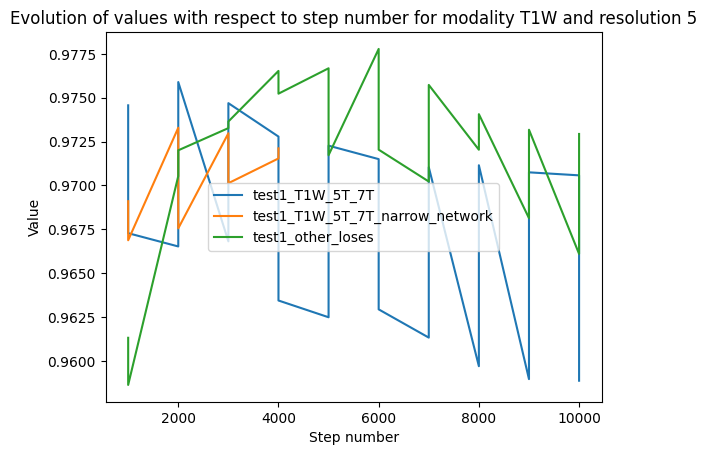

In [ ]:
models_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/test2_direct_dummy_conversion/training/models/"
model_name_list = ["test1_T1W_5T_7T", "test1_T1W_5T_7T_narrow_network", "test1_other_loses"]

def create_val_csv_files(models_path, model_name):
    csv_files = []
    for root, dirs, files in os.walk(os.path.join(models_path, model_name)):
        for file in files:
            if file.startswith("step_") and file.endswith("_metrics.csv"):
                csv_files.append(os.path.join(root, file))

    # read csvs
    complete_csv = []
    for file in csv_files:
        df = pd.read_csv(file)
        step = int(os.path.basename(file).split("step_")[1].split("_metrics.csv")[0])
        df["step"] = step
        complete_csv.append(df)

    complete_csv = pd.concat(complete_csv, ignore_index=True)
    complete_csv = complete_csv.sort_values(by="step")
    complete_csv = complete_csv[complete_csv["step"] != 1]

    return complete_csv


models_csvs = {}
for model_name in model_name_list:
    models_csvs[model_name] = create_val_csv_files(models_path, model_name)

modality = "T1W"
resolution = 5

metric_to_plot = "ssim" #mse,mae,ssim
for model_name in model_name_list:
    results_df = models_csvs[model_name]
    results_df = results_df[(results_df["modality"] == modality) & (results_df["resolution"] == resolution)]
    plt.plot(results_df["step"], results_df[metric_to_plot], label=f"{model_name}")
    plt.xlabel("Step number")
    plt.ylabel("Value")
    plt.title(f"Evolution of values with respect to step number for modality {modality} and resolution {resolution}")
    plt.legend()
plt.show()




